#***Microproyecto 1 - Generación de paleta de colores a partir de imágenes con técnicas de machine learning no supervisado***
###Omar Dario Diaz H.
###Diego Andres Burbano A.

In [ ]:
import cv2
import os
import pandas as pd
import numpy as np
from google.colab import drive
from PIL import Image
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import matplotlib.cm as cm
from sklearn.cluster import estimate_bandwidth
from sklearn.cluster import MeanShift
from sklearn.manifold import TSNE
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.cluster import KMeans, DBSCAN, MeanShift


# ***1. Recopilación y presentación de las imagenes***

Se seleccionan y se cargan cuatro imágenes de cuatro estilos diferentes:


*   Impresionismo
*   Cubismo
*   Pop Art
*   Expresionismo Abstracto

Los criterios para seleccionar estos cuatro estilos ya que con ellos se cubre una gran variedad de características cromáticas visuales dentro de las que se destacan: Naturalismo colorido (Impresionismo), estructura geométrica y tonos apagados (Cubismo), explosión de colores (Expresionismo Abstracto) y colores planos, saturados y contraste (Pop Art). Estas características nos garantizan:

1. Riqueza de colores
2. Consistencia interna clara: facilita que los algoritmos de clustering identifiquen patrones significativos dentro de cada estilo.
3. Diversidad visual
4. Buena representación en el dataset: garantizando estilos que ofrezcan una gran variedad de imágenes.  
5. Interpretabilidad: Son estilos reconocidos facilmente, lo que ofrece valor significativo a los resultados.


In [ ]:
drive.mount('/content/drive', force_remount=True)

#Ruta Local Omar B.
#os.chdir('/content/drive/MyDrive/ColabNotebooks/MaestriaUniandesColabs/ML_No_Supervisado/Micro_proyecto/Imagenes/New_Realism')


# Ruta Local Diego B.
os.chdir('/content/drive/MyDrive/datos/Images')

Mounted at /content/drive


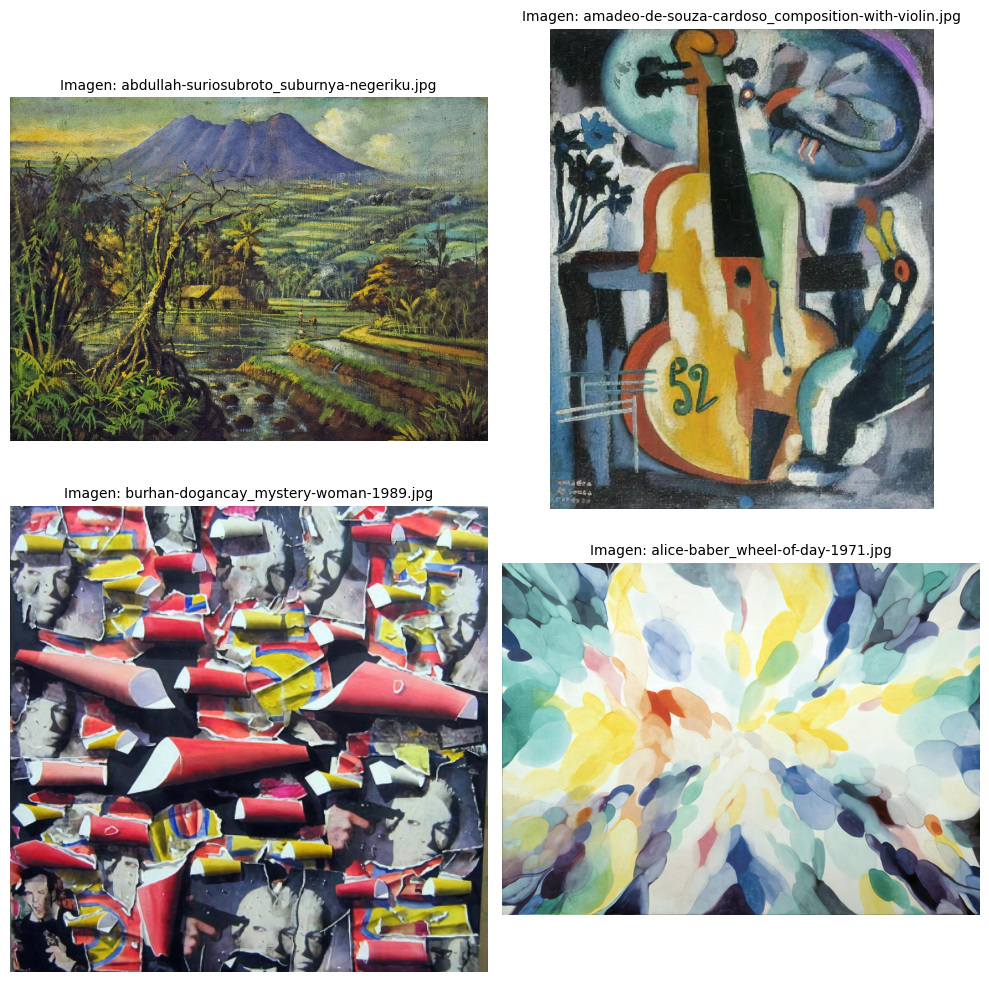

In [ ]:
# Estilo Impresionismo
imagen1 = "abdullah-suriosubroto_suburnya-negeriku.jpg"
# Estilo Cubismo
imagen2 = "amadeo-de-souza-cardoso_composition-with-violin.jpg"
# Estilo Pop-Art
imagen3 = "burhan-dogancay_mystery-woman-1989.jpg"
# Estilo Expresionismo abstracto
imagen4 = "alice-baber_wheel-of-day-1971.jpg"



lista_imagenes = [imagen1, imagen2, imagen3, imagen4]
imagenes_original = list()

def cargar_imagenes(lista_imagenes):
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    imagenes = []

    for ax, nombrearchivo in zip(axes.flat, lista_imagenes):
        imagen = cv2.imread(nombrearchivo)
        if imagen is None:
            print(f"No se pudo cargar la imagen: {nombrearchivo}")
            continue
        imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
        imagenes.append((nombrearchivo, imagen))
        imagenes_original.append(imagen)

        ax.imshow(imagen)
        ax.set_title(f'Imagen: {nombrearchivo}', fontsize=10)
        ax.axis('off')

    plt.tight_layout()
    plt.show()
    return imagenes, imagenes_original
imagenes, imagenes_original = cargar_imagenes(lista_imagenes)


Importante destacar que en el momento de la presentación de las imágenes estamos desarrollando la transformación de las imágenes a formato RGB para garantizar que las mismas puedan ser presentadas adecuadamente en el notebook. La representación en RGB nos ofrece los siguientes beneficios en el proceso de Clustering:
1. Uniformidad del espacio color ya que todas quedan el espacio de 3 dimensiones (R, G, B) garantizando comparaciones consistentes.
2. Representación directa para cada clustering al convertir cada pixel en un espacio de 3 dimensiones ofreciendole al algoritmo facilidad en la busqueda de colores similares.
3. Facilidad para extraer paletas de color ya que el formato permite identificar colores dominantes facilimente.
4. Compatibilidad con métricas ya que se pueden utilizar distancias Euclideas o Manhattan (para agrupar colores similares).
5. Representación de colores en el mismo rango, ya que los pixeles se encuentran en el mismo rango (0 a 255) facilitando la normalización (0 a 1)

# ***2. Preparación de los datos y construcción del pipeline***

Como parte del proceso de transformación de datosy  adicional a la conversión RGB mencionada con anterioridad, se configura la función 'transformacion' con la cual preparamos para las imágenes a procesar asi:
1. Redimensionando la imagen a un formato 100 pixeles x 100 pixeles, reduciendo la imagen a un tamaño fijo y manejable, garantizando uniformidad entre las muestras y disminuyendo carga computacional.
2. Normalizando el formato de cada pixel (convirtiendolo de 0 a 255 al rango 0 a 1) facilitando la convergencia de los algoritmos de clustering.
3. Proceso de reshape para convertir la imagen en un arreglo de dos dimensiones donde cada fila representa un pixel, permitiendo a los algoritmos que trabajen sobre los vectores de color.

In [ ]:
# Paso 1: Transformación de imagen
def transformacion(imagen):
    imagen = cv2.resize(imagen, (100, 100))  # Redimensiona la imagen
    imagen_np = np.array(imagen)/255 # Normalizar
    imagen_aplanado = imagen_np.reshape((-1, 3))  # Aplana la imagen a una matriz de píxeles RGB
    return imagen_aplanado  # Devuelve la imagen transformada

# ***3. Construcción del modelo, selección de hiperparámetros y evaluación del mejor modelo***

Para resolver el problema de clustering hemos seleccionado un algoritmo basado en prototipo (K-means) y dos basados en densidades (DBSCAN y Mean Shift).


*   K-means: se selecciona este algoritmo por su capacidad de resolver problemas de clustering de manera eficiente con baja carga computacional. Es particularmente adecuado para la agrupación de colores en el espacio RGB, ya que asume clusters de forma esférica y tamaños similares. Adicionalmente, al generar centroides representativos para cada cluster, permite definir colores de referencia que pueden ser utilizados en etapas posteriores del programa como paleta de colores seleccionada. Su eficiencia y facilidad de replicación lo convierten en un modelo base sólido para nuestro análisis.
*   DBSCAN: Se selecciona este algoritmo ya que ofrece la posiblidad de identificar clusters de manera arbitraria sin tener la necesidad de ingresar el numero de colores. Con un adecuado manejo de sus hiperparámetros podemos controlar el ruido de la imagen descartando colores poco representativos que no aportan valor.  
*   Mean Shift: Al igual que DBSCAN, Mean Shift identifica el número de clusters en los datos donde el número de colores no es conocido de antemano. Este algoritmo permite identificar colores de mayor densidad en el espacio de características permitiendo una segmentación mas adaptativa. Adicionalmente su manejo de clusters no esféricos nos permitirá capturar mejor la diversidad cromática de las imágenes.  






Para la selección de los mejores hiperparámetros y posteriormente para evaluación del modelo hemos seleccionado las siguientes métricas:


*   Score de silueta: Se selecciona porque mide la cohesión y separación de cada cluster.
*   Calinski-Harabasz: Nos permite medir densidad intra-cluster y dispersión inter-cluster.

La combinación de las dos metricas ofrecen un gran complemento ofreciendo una evaluación robusta ofreciendo visión de calidad de cada cluster: similitud interna y externa al mismo tiempo que CH refuerza analisis cuantitativo de dispersión y compactación.



In [ ]:
# Función para evaluar el mejor modelo
def evaluar_modelo(X, etiquetas, metrica):
    etiquetas = np.array(etiquetas)

    # Filtrar ruido (etiquetas == -1)
    if -1 in etiquetas:
        X = X[etiquetas != -1]
        etiquetas = etiquetas[etiquetas != -1]

    # Verificar que haya al menos 2 clusters
    if len(set(etiquetas)) <= 1:
        return -1

    if metrica == 'silhouette':
        return silhouette_score(X, etiquetas)
    elif metrica == 'calinski_harabasz':
        return calinski_harabasz_score(X, etiquetas)
    else:
        raise ValueError("Métrica no soportada")

# Función para evaluar los mejores hiperparámetros dentro de cada modelo seleccionado
def buscar_hiperparametros_evaluar(X, metrica):
    resultados = []
    # K-MEANS
    for k in range(2, 10):
        modelo = KMeans(n_clusters=k, random_state=0).fit(X)
        score = evaluar_modelo(X, modelo.labels_, metrica)
        resultados.append(('KMeans', modelo, score, {'n_clusters': k}))

    # DBSCAN
    for eps in [0.1, 0.2, 0.5, 1, 2, 5]:
        for min_samples in [5, 10, 25, 50, 250]:
            modelo = DBSCAN(eps=eps, min_samples=min_samples, metric='manhattan').fit(X)
            score = evaluar_modelo(X, modelo.labels_, metrica)
            resultados.append(('DBSCAN', modelo, score, {'eps': eps, 'min_samples': min_samples}))
    #MEAN SHIFT
    for q in [0.05, 0.08, 0.1, 0.12, 0.15]:
        bandwidth = estimate_bandwidth(X, quantile=q, n_samples=1000)
        modelo = MeanShift(bandwidth=bandwidth, bin_seeding=True).fit(X)
        score = evaluar_modelo(X, modelo.labels_, metrica)
        resultados.append(('MeanShift', modelo, score, {'quantile': q}))

    mejor = max(resultados, key=lambda x: x[2])
    mejor_modelo_kmeans = max(
    [r for r in resultados if r[0] == 'KMeans'],
    key=lambda x: x[2])
    mejor_modelo_dbscan = max(
    [r for r in resultados if r[0] == 'DBSCAN'],
    key=lambda x: x[2])
    mejor_modelo_meanshift = max(
    [r for r in resultados if r[0] == 'MeanShift'],
    key=lambda x: x[2])

    print("Mejores hiperparámetros para cada modelo evaluado:")
    print(f"Mejor modelo K.means: {mejor_modelo_kmeans[0]} con score={mejor_modelo_kmeans[2]:.4f} y mejores hiperparámetros={mejor_modelo_kmeans[3]}")
    print(f"Mejor modelo DBSCAN: {mejor_modelo_dbscan[0]} con score={mejor_modelo_dbscan[2]:.4f} y mejores hiperparámetros={mejor_modelo_dbscan[3]}")
    print(f"Mejor modelo MeanShift: {mejor_modelo_meanshift[0]} con score={mejor_modelo_meanshift[2]:.4f} y mejores hiperparámetros={mejor_modelo_meanshift[3]}")

    print(f"Mejor modelo: {mejor[0]} con score={mejor[2]:.4f} y parámetros={mejor[3]}")
    return mejor, resultados

# Función para generar tabla comparativa de modelos con sus métricas y parámetros:
def generar_tabla_resutlados(resultados):
    tabla_resultados = []
    for nombre_modelo, modelo, score, parametros in resultados:
            tabla_resultados.append({
                'Imagen': i,
                'Modelo': nombre_modelo,
                'Score': score,
                'Parametros': parametros
            })

    df_resultados = pd.DataFrame(tabla_resultados)
    print(df_resultados)

    return df_resultados

# ***4. Construcción de la función que transforma los grupos de colores en un muestrario representativo***

Se presenta el desarrollo de la función 'generar_paleta_general' con la cual, a partir del modelo ajustado y con los pixeles de la imagen, se genera la paleta de colores mas representativos de cada imagen, indicando la frecuencia de aparición de cada color en el espacio redimensionado.

In [ ]:
# Función para generar la paleta de colores mas representativos
def generar_paleta_general(modelo, X):
    etiquetas = modelo.labels_
    conteo = Counter(etiquetas)
    hex_colors = []
    freqs = []

    for idx, count in conteo.items():
        if idx == -1:
            continue

        cluster_points = X[etiquetas == idx]
        color = cluster_points.mean(axis=0)

        # Convertir a formato RGB [0-255] para indicar en la paleta el color que vamos a graficar en formato hexagesimal
        color = np.clip((color * 255).astype(int), 0, 255)
        hex_color = "#{:02x}{:02x}{:02x}".format(*color)

        hex_colors.append(hex_color)
        freqs.append(count)

    # Graficar paleta
    plt.figure(figsize=(10, 4))
    plt.bar(range(len(hex_colors)), freqs, color=hex_colors, width=0.8)
    plt.xticks(range(len(hex_colors)), hex_colors, rotation=45, ha="right")
    plt.title("Paleta de Colores - Frecuencia")
    plt.ylabel("Frecuencia de píxeles")
    plt.tight_layout()
    plt.show()


In [ ]:
def visualizar_tsne_mejor_modelo(X, etiquetas, nombre_modelo, sample_size=500):
    X_norm = X / np.max(X)
    if X.shape[0] > sample_size:
        idx = np.random.choice(X.shape[0], sample_size, replace=False)
        X_sample = X_norm[idx]
        etiquetas_sample = etiquetas[idx]
    else:
        X_sample = X_norm
        etiquetas_sample = etiquetas
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=500)
    X_2d = tsne.fit_transform(X_sample)
    plt.figure(figsize=(7, 7))
    clusters = np.unique(etiquetas_sample)
    for i in clusters:
        color = 'gray' if i == -1 else plt.cm.tab10(i % 10)
        label = 'Ruido' if i == -1 else f'Cluster {i}'
        puntos = X_2d[etiquetas_sample == i]
        plt.scatter(puntos[:, 0], puntos[:, 1], s=8, color=color, label=label)
    plt.legend()
    plt.title(f"t-SNE - {nombre_modelo}")
    plt.savefig(f"t-SNE_{nombre_modelo}.png")
    plt.show()

#***5. Evidencia de desempeño***

***Programa principal:***

***METRICA: Calinski-Harabasz***
Mejores hiperparámetros para cada modelo evaluado:
Mejor modelo K.means: KMeans con score=18246.4504 y mejores hiperparámetros={'n_clusters': 2}
Mejor modelo DBSCAN: DBSCAN con score=-1.0000 y mejores hiperparámetros={'eps': 0.1, 'min_samples': 5}
Mejor modelo MeanShift: MeanShift con score=18188.8784 y mejores hiperparámetros={'quantile': 0.12}
Mejor modelo: KMeans con score=18246.4504 y parámetros={'n_clusters': 2}
Cantidad de clusters válidos: 2
    Imagen     Modelo         Score                        Parametros
0        0     KMeans  18246.450378                 {'n_clusters': 2}
1        0     KMeans  16880.915891                 {'n_clusters': 3}
2        0     KMeans  14726.172314                 {'n_clusters': 4}
3        0     KMeans  14313.617519                 {'n_clusters': 5}
4        0     KMeans  13701.748413                 {'n_clusters': 6}
5        0     KMeans  13786.435812                 {'n_clusters': 7}
6        0     KMeans  1

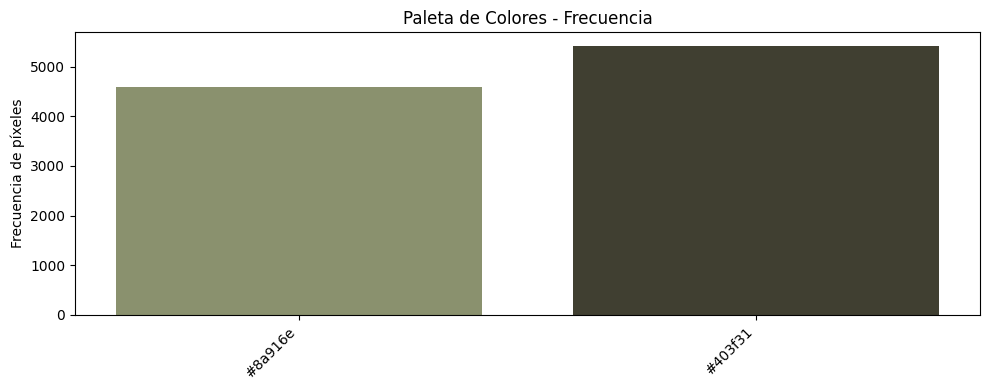

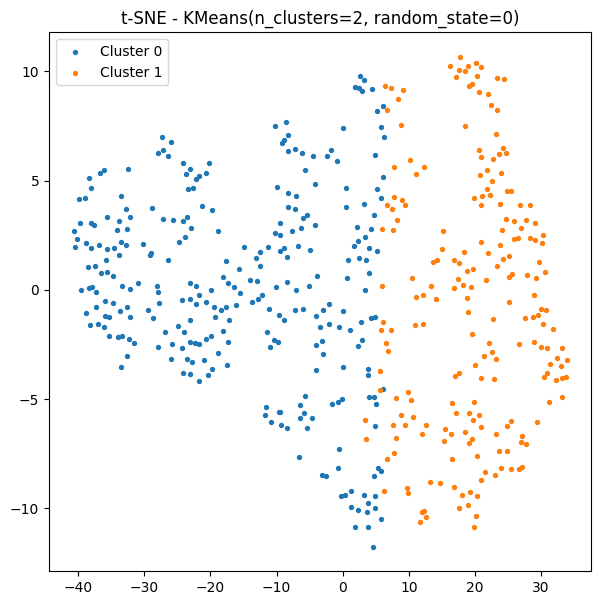

Mejores hiperparámetros para cada modelo evaluado:
Mejor modelo K.means: KMeans con score=21859.4097 y mejores hiperparámetros={'n_clusters': 9}
Mejor modelo DBSCAN: DBSCAN con score=699.5666 y mejores hiperparámetros={'eps': 0.1, 'min_samples': 250}
Mejor modelo MeanShift: MeanShift con score=18209.3861 y mejores hiperparámetros={'quantile': 0.08}
Mejor modelo: KMeans con score=21859.4097 y parámetros={'n_clusters': 9}
Cantidad de clusters válidos: 9
    Imagen     Modelo         Score                        Parametros
0        1     KMeans  16419.665540                 {'n_clusters': 2}
1        1     KMeans  16173.082112                 {'n_clusters': 3}
2        1     KMeans  19503.124989                 {'n_clusters': 4}
3        1     KMeans  19903.008802                 {'n_clusters': 5}
4        1     KMeans  19067.634524                 {'n_clusters': 6}
5        1     KMeans  21786.697063                 {'n_clusters': 7}
6        1     KMeans  21314.605909                 {'

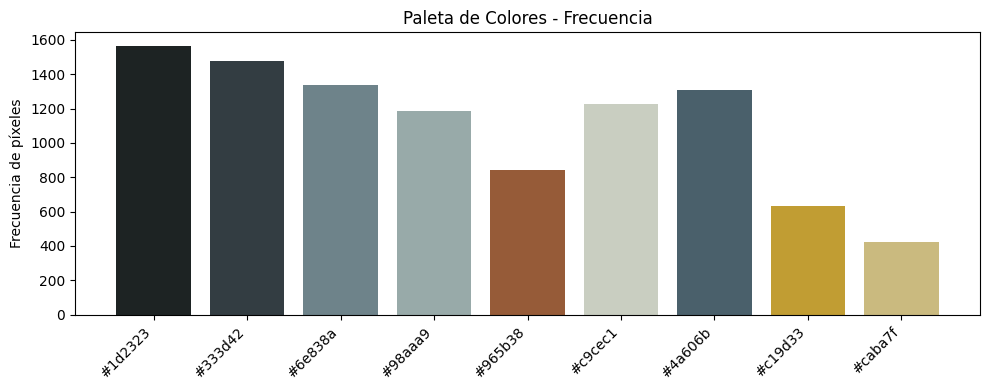

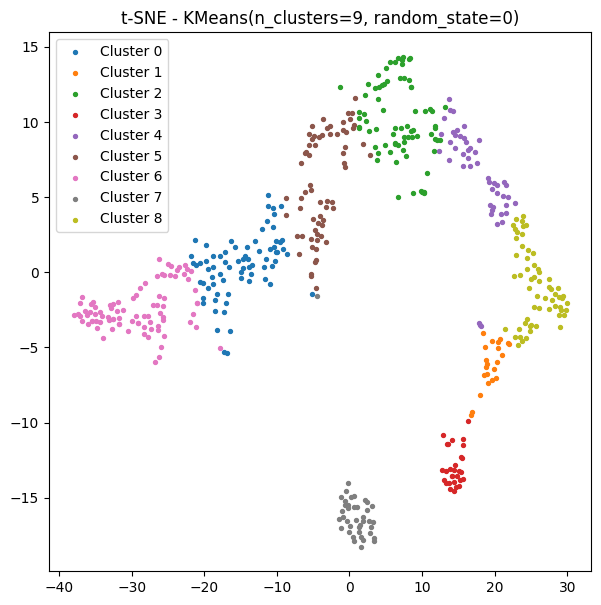

Mejores hiperparámetros para cada modelo evaluado:
Mejor modelo K.means: KMeans con score=18282.1064 y mejores hiperparámetros={'n_clusters': 2}
Mejor modelo DBSCAN: DBSCAN con score=59111.9124 y mejores hiperparámetros={'eps': 0.1, 'min_samples': 250}
Mejor modelo MeanShift: MeanShift con score=14692.0925 y mejores hiperparámetros={'quantile': 0.12}
Mejor modelo: DBSCAN con score=59111.9124 y parámetros={'eps': 0.1, 'min_samples': 250}
Cantidad de clusters válidos: 2
    Imagen     Modelo         Score                        Parametros
0        2     KMeans  18282.106396                 {'n_clusters': 2}
1        2     KMeans  17861.214359                 {'n_clusters': 3}
2        2     KMeans  16658.644424                 {'n_clusters': 4}
3        2     KMeans  15919.561507                 {'n_clusters': 5}
4        2     KMeans  16519.174313                 {'n_clusters': 6}
5        2     KMeans  16065.539046                 {'n_clusters': 7}
6        2     KMeans  16372.134498  

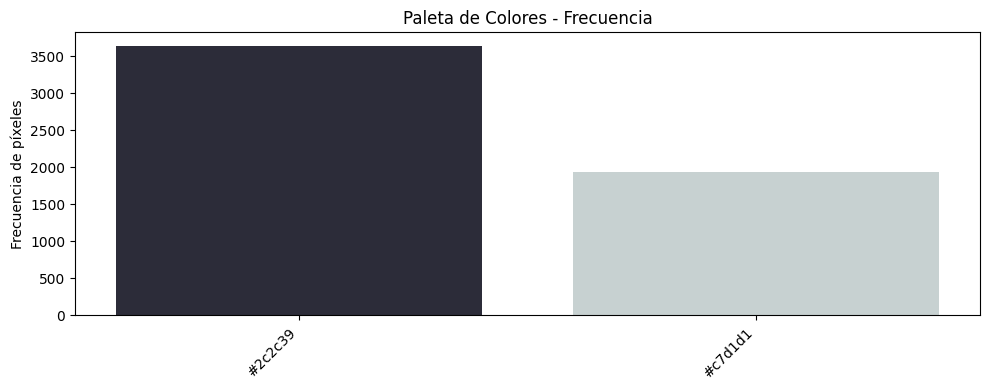

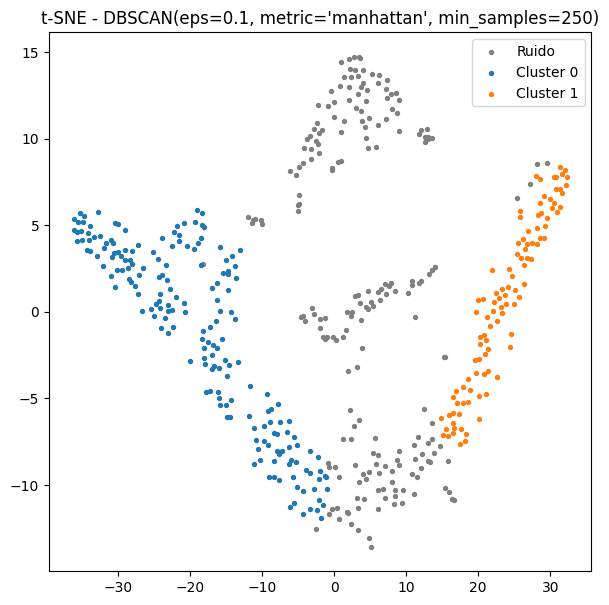

Mejores hiperparámetros para cada modelo evaluado:
Mejor modelo K.means: KMeans con score=16820.6424 y mejores hiperparámetros={'n_clusters': 5}
Mejor modelo DBSCAN: DBSCAN con score=150.7262 y mejores hiperparámetros={'eps': 0.2, 'min_samples': 50}
Mejor modelo MeanShift: MeanShift con score=9111.5186 y mejores hiperparámetros={'quantile': 0.1}
Mejor modelo: KMeans con score=16820.6424 y parámetros={'n_clusters': 5}
Cantidad de clusters válidos: 5
    Imagen     Modelo         Score                        Parametros
0        3     KMeans  16444.007319                 {'n_clusters': 2}
1        3     KMeans  11727.281203                 {'n_clusters': 3}
2        3     KMeans  15809.106662                 {'n_clusters': 4}
3        3     KMeans  16820.642374                 {'n_clusters': 5}
4        3     KMeans  16403.239697                 {'n_clusters': 6}
5        3     KMeans  15578.853986                 {'n_clusters': 7}
6        3     KMeans  15323.703484                 {'n_c

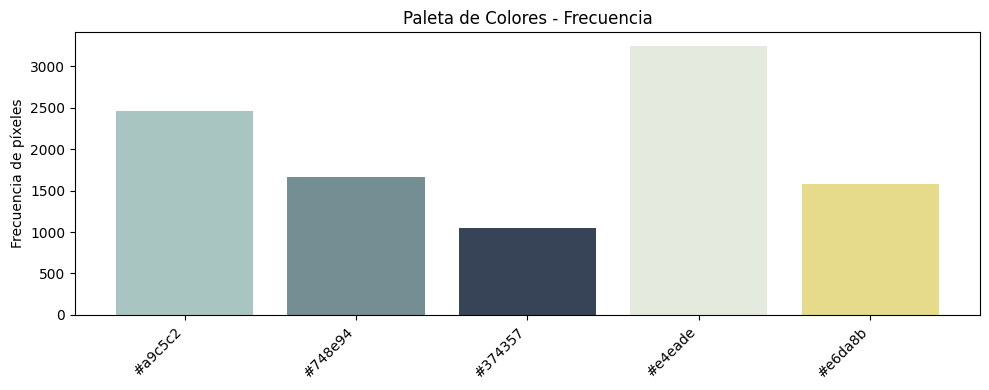

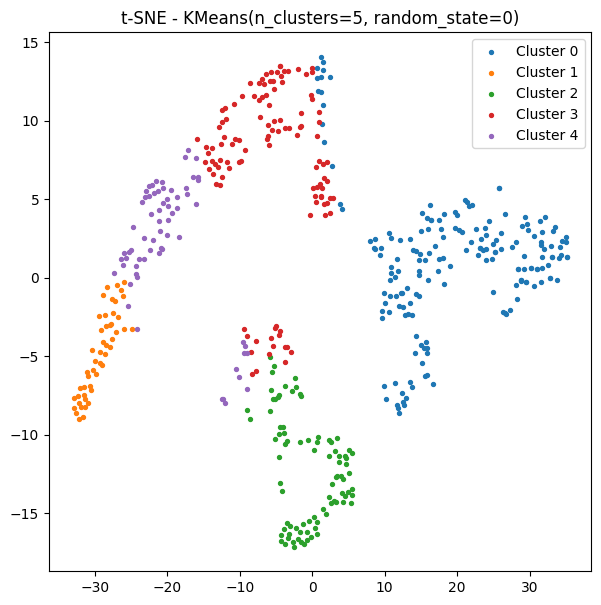

In [ ]:
#Programa principal utilizando la metrica Calinski-Harabansz para selección de hiperparámetros y evaluación de modelo
modelo_optimo_list = list()
print("***METRICA: Calinski-Harabasz***")
for i in range(len(imagenes_original)):
    imagen = imagenes_original[i]                   # tomar solo una imagen
    imagen_transformada = transformacion(imagen)    # transformar la imagen entera
    mejor_modelo, resultados = buscar_hiperparametros_evaluar(imagen_transformada, metrica="calinski_harabasz")
    modelo_seleccionado = mejor_modelo[1]
    etiquetas = modelo_seleccionado.labels_
    clusters_validos = set(etiquetas) - {-1}
    print("Cantidad de clusters válidos:", len(clusters_validos))
    df_resultados = generar_tabla_resutlados(resultados)
    generar_paleta_general(modelo_seleccionado, imagen_transformada)
    visualizar_tsne_mejor_modelo(imagen_transformada, etiquetas, modelo_seleccionado)



***METRICA: Silhouette***
Mejores hiperparámetros para cada modelo evaluado:
Mejor modelo K.means: KMeans con score=0.5337 y mejores hiperparámetros={'n_clusters': 2}
Mejor modelo DBSCAN: DBSCAN con score=-1.0000 y mejores hiperparámetros={'eps': 0.1, 'min_samples': 5}
Mejor modelo MeanShift: MeanShift con score=0.5327 y mejores hiperparámetros={'quantile': 0.12}
Mejor modelo: KMeans con score=0.5337 y parámetros={'n_clusters': 2}
Cantidad de clusters válidos: 2
    Imagen     Modelo     Score                        Parametros
0        0     KMeans  0.533681                 {'n_clusters': 2}
1        0     KMeans  0.444762                 {'n_clusters': 3}
2        0     KMeans  0.372390                 {'n_clusters': 4}
3        0     KMeans  0.387583                 {'n_clusters': 5}
4        0     KMeans  0.369043                 {'n_clusters': 6}
5        0     KMeans  0.361739                 {'n_clusters': 7}
6        0     KMeans  0.337904                 {'n_clusters': 8}
7    

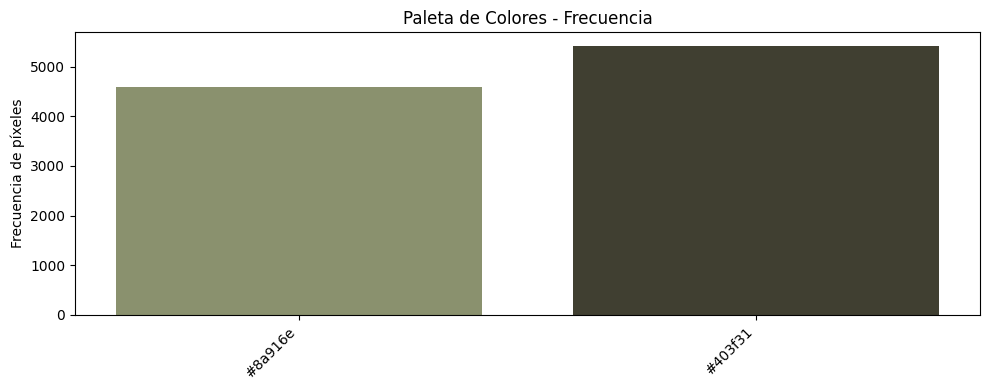

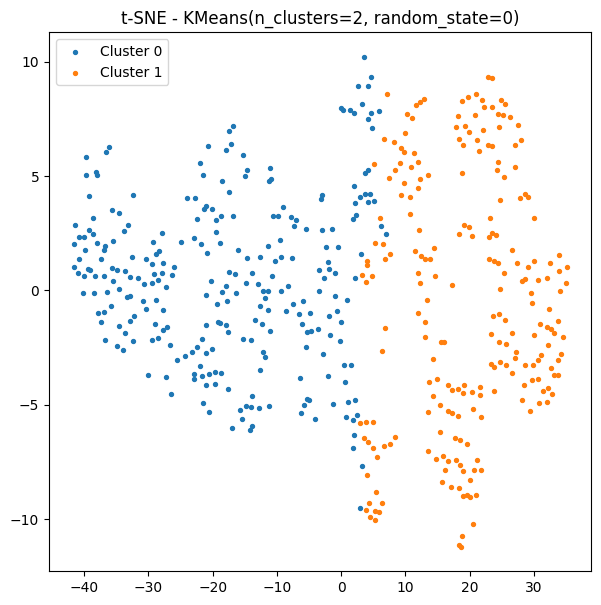

Mejores hiperparámetros para cada modelo evaluado:
Mejor modelo K.means: KMeans con score=0.5290 y mejores hiperparámetros={'n_clusters': 4}
Mejor modelo DBSCAN: DBSCAN con score=0.2875 y mejores hiperparámetros={'eps': 0.1, 'min_samples': 250}
Mejor modelo MeanShift: MeanShift con score=0.5245 y mejores hiperparámetros={'quantile': 0.12}
Mejor modelo: KMeans con score=0.5290 y parámetros={'n_clusters': 4}
Cantidad de clusters válidos: 4
    Imagen     Modelo     Score                        Parametros
0        1     KMeans  0.514799                 {'n_clusters': 2}
1        1     KMeans  0.466040                 {'n_clusters': 3}
2        1     KMeans  0.528961                 {'n_clusters': 4}
3        1     KMeans  0.477093                 {'n_clusters': 5}
4        1     KMeans  0.436441                 {'n_clusters': 6}
5        1     KMeans  0.460083                 {'n_clusters': 7}
6        1     KMeans  0.459537                 {'n_clusters': 8}
7        1     KMeans  0.43013

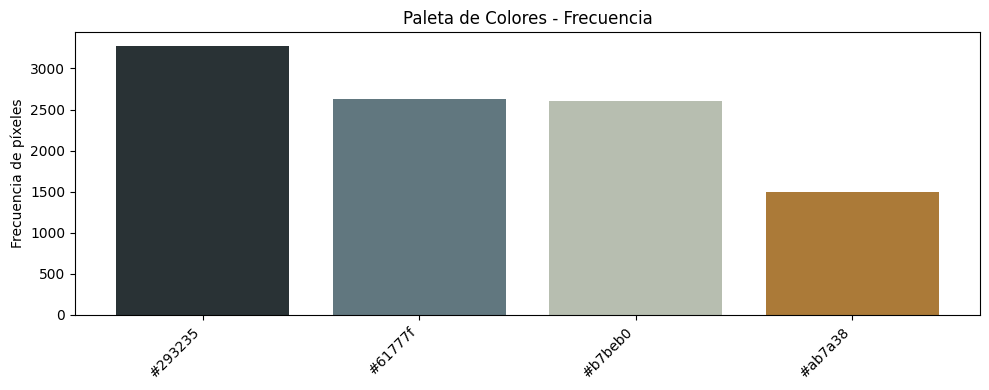

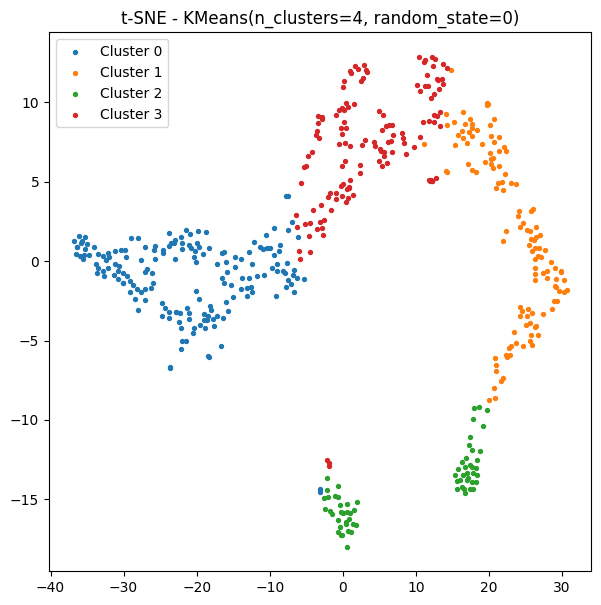

Mejores hiperparámetros para cada modelo evaluado:
Mejor modelo K.means: KMeans con score=0.5417 y mejores hiperparámetros={'n_clusters': 2}
Mejor modelo DBSCAN: DBSCAN con score=0.8184 y mejores hiperparámetros={'eps': 0.1, 'min_samples': 250}
Mejor modelo MeanShift: MeanShift con score=0.4828 y mejores hiperparámetros={'quantile': 0.15}
Mejor modelo: DBSCAN con score=0.8184 y parámetros={'eps': 0.1, 'min_samples': 250}
Cantidad de clusters válidos: 2
    Imagen     Modelo     Score                        Parametros
0        2     KMeans  0.541663                 {'n_clusters': 2}
1        2     KMeans  0.483347                 {'n_clusters': 3}
2        2     KMeans  0.466816                 {'n_clusters': 4}
3        2     KMeans  0.420626                 {'n_clusters': 5}
4        2     KMeans  0.452603                 {'n_clusters': 6}
5        2     KMeans  0.456092                 {'n_clusters': 7}
6        2     KMeans  0.419379                 {'n_clusters': 8}
7        2     

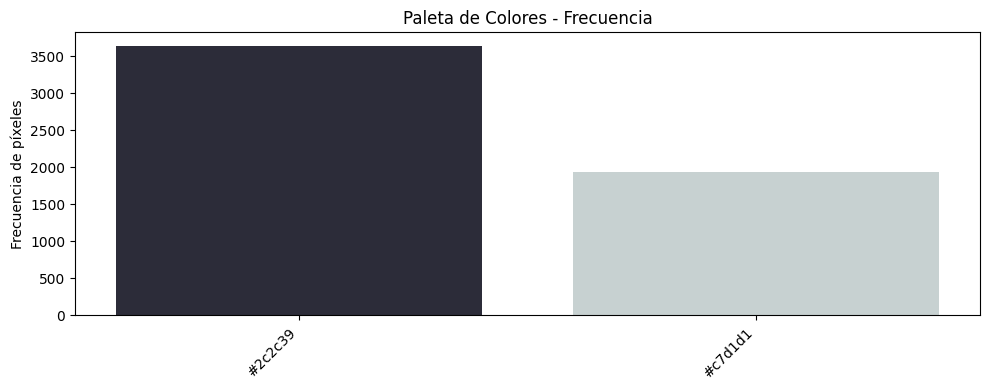

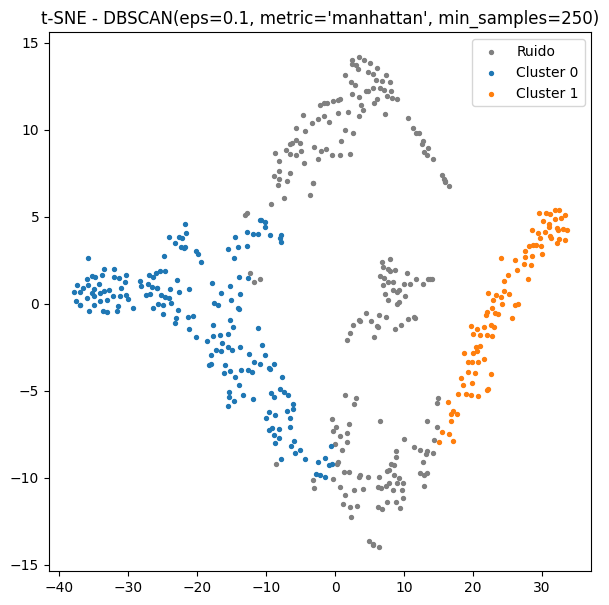

Mejores hiperparámetros para cada modelo evaluado:
Mejor modelo K.means: KMeans con score=0.5657 y mejores hiperparámetros={'n_clusters': 2}
Mejor modelo DBSCAN: DBSCAN con score=0.3818 y mejores hiperparámetros={'eps': 0.1, 'min_samples': 25}
Mejor modelo MeanShift: MeanShift con score=0.4559 y mejores hiperparámetros={'quantile': 0.15}
Mejor modelo: KMeans con score=0.5657 y parámetros={'n_clusters': 2}
Cantidad de clusters válidos: 2
    Imagen     Modelo     Score                        Parametros
0        3     KMeans  0.565691                 {'n_clusters': 2}
1        3     KMeans  0.407383                 {'n_clusters': 3}
2        3     KMeans  0.462374                 {'n_clusters': 4}
3        3     KMeans  0.450635                 {'n_clusters': 5}
4        3     KMeans  0.425306                 {'n_clusters': 6}
5        3     KMeans  0.391013                 {'n_clusters': 7}
6        3     KMeans  0.394786                 {'n_clusters': 8}
7        3     KMeans  0.365406

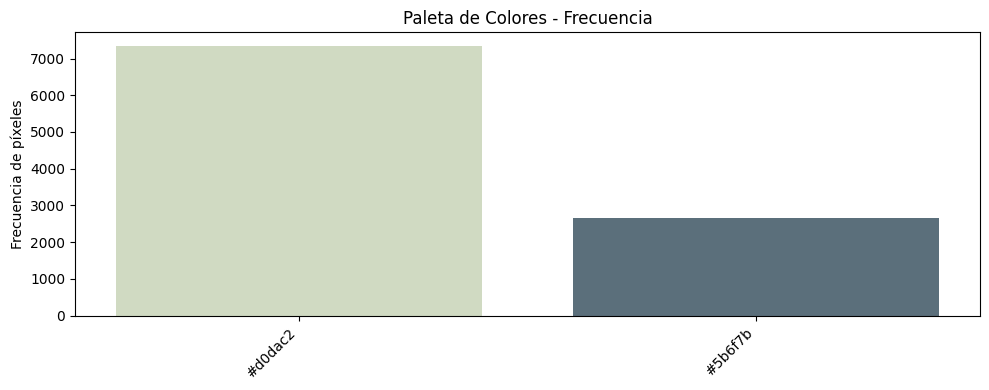

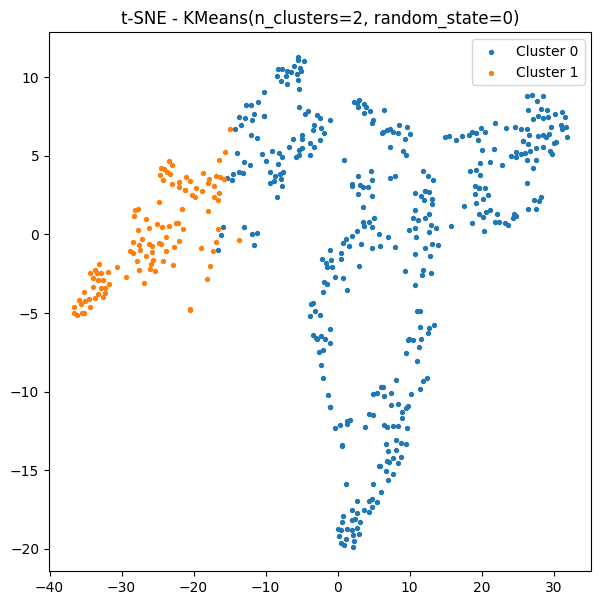

In [ ]:
#Programa principal utilizando la metrica Silhouette para selección de hiperparámetros y evaluación de modelo
modelo_optimo_list = list()
print("***METRICA: Silhouette***")
for i in range(len(imagenes_original)):
    imagen = imagenes_original[i]                   # tomar solo una imagen
    imagen_transformada = transformacion(imagen)    # transformar la imagen entera
    mejor_modelo, resultados = buscar_hiperparametros_evaluar(imagen_transformada, metrica="silhouette")
    modelo_seleccionado = mejor_modelo[1]
    etiquetas = modelo_seleccionado.labels_
    clusters_validos = set(etiquetas) - {-1}
    print("Cantidad de clusters válidos:", len(clusters_validos))
    df_resultados = generar_tabla_resutlados(resultados)
    generar_paleta_general(modelo_seleccionado, imagen_transformada)
    visualizar_tsne_mejor_modelo(imagen_transformada, etiquetas, modelo_seleccionado)

#***6. Análisis de resultados y conclusiones***



*   Considerando los resultados obtenidos, se observa el gran desempeño del modelo K-means. Si bien es requerido calcular el número de clusters, lo cual en principio puede ser una desventaja, esto es sobrepasado ampliamente por su simplicidad y gran capacidad de agrupamiento con un bajo costo computacional.
*   Observamos que el modelo K-means es el mejor modelo para 3 de las 4 imágenes. Una posible razón de esto, es que dichas imágenes estan en general dominadas por pocos colores, ya que se trata propiamente de pinturas, en las cuales existe una limitación en la mezcla o número de colores, de ahí que los clusteres son relativamente pequeños de 2 a 4.
*   Para el caso particular de la imagen 3, que corresponde al estilo Pop Art, vemos que en sí no se trata de una pintura sino más bien de un collage fotográfico, con gran diversidad cromática, diversas texturas y patrones irregulares. Esto dificulta la capacidad de agrupamiento de K-means por su técnica de centroides mas apropiada para distribuciones de colores homogeneas y con formas definidas. En contraste el modelo DBSCAN sobrepasa ampliamente el scoring de los otros dos modelos debido a su técnica de agrupamiento basada en radio de vecindad y mínimo número de puntos que permite identificar regiones cromáticas consistentes incluso en contextos irregulares y no lineales. DBSCAN es más robusto en presencia de ruido y puede detectar estructuras menos convencionales.
*   En este caso práctico, Mean Shift se mostró como una alternativa intermedia: ofrece cierta diversidad de clusters y flexibilidad al no requerir un número predefinido, pero no logra superar a DBSCAN en escenarios de alta densidad cromática ni a K-Means en imágenes más homogéneas. Su mayor potencial estaría en contextos donde no se conoce de antemano el número de grupos y se necesita un método adaptable a formas de clusters irregulares, aunque con la desventaja de mayor costo computacional.
*   Los resultados muestran que tanto con el índice de Silhouette como con el de Calinski-Harabasz (CH), los mejores modelos seleccionados coinciden en términos generales, confirmando la consistencia de las métricas en la elección del algoritmo más adecuado. Sin embargo, al comparar ambas, se observa que CH tiende a generar soluciones con un mayor número de clústeres. Esto se explica porque CH se centra en maximizar la compacidad intra-clúster y la separación inter-clúster, lo que favorece la segmentación de paletas cromáticas más diversas en las imágenes, incluso si los grupos presentan solapamiento. Por su parte, Silhouette prioriza la cohesión y separación global de cada clúster, por lo que tiende a penalizar soluciones con demasiados grupos poco diferenciados.
En consecuencia, CH resulta más sensible a la riqueza cromática y a la dispersión de colores, mientras que Silhouette es más conservador, privilegiando configuraciones de pocos clústeres pero más cohesionados. La complementariedad de ambas métricas ofrece un panorama más robusto: mientras Silhouette asegura soluciones compactas y claras, CH aporta detalle adicional en la segmentación de texturas y paletas complejas.
*   Con base en los resultados obtenidos y en la capacidad que tienen los algoritmos de clustering para identificar y agrupar colores, podemos concluir que este tipo de soluciones presenta un alto potencial de aplicación en la industria y el mercado, destacándose en aplicaciones de control de calidad y manufactura por medio de identificación de defectos o desviaciones de color en productos; en la industria de alimentos y bebidas, a través de clasificación de madurez en frutas y verduras, o en la industria cosmética apoyando en la segmentación de tipos de piel para personalizar maquillaje. Igualmente podemos resaltar los casos de uso de diagnóstico médico en telemedicina e IA en radiología ya que en el postprocesamiento de imágenes radiológicas se utilizan pseudocolores para resaltar estructuras segmentando regiones de interés de manera automática. Finalmente en el procesamiento de imágenes satelitales apoyando en aplicaciones de identificación de áreas cultivadas vs. no cultivadas, monitoreo y segmentación de estado de cultivos entre otros.
*   En los casos mencionados, estas aplicaciones ofrecen beneficios concretos como la automatización de procesos de clasificación, el análisis de tendencias y patrones en tiempo real, el aumento de la precisión diagnóstica, la detección temprana de enfermedades críticas y, en general, un apoyo directo en la toma de decisiones estratégicas y operativas en distintos sectores productivos.
*   Finalmente podemos concluir que la elección del algoritmo de clustering no solo depende de los hiperparámetros, sino también de la naturaleza artística y estructural de la imagen analizada.
